# Project 2: Healthcare Analytics Project – Data Cleaning & Visualization

**Student Name**: Garvit Mathur  
**Objective**: Clean and prepare patient medical records for accurate clinical analysis and visualization.  
**Dataset**: Hospital patient data with missing values, inconsistencies, and formatting issues  
**Tools**: Python, Pandas, Matplotlib, Seaborn


Step 1: Load Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file = "healthcare_patient_data.csv"
df = pd.read_csv(file)

In [4]:
df.head()

,PatientID,Name,Gender,Age,VisitDate,Department,Diagnosis,BloodPressure,Notes
0,1,Evan Diaz,-,77.0,2023-02-10,Cardiology,NaN,164/60,NaN
1,2,Chelsea Price,M,60.0,2022-12-15,Cardiology,Flu,95/78,Choose significant he foot type.
2,3,Todd Gutierrez,Female,22.0,2022-11-24,Cardiology,Diabetes,-,Happy protect maybe open be team.
3,4,Olivia Hale,unknown,74.0,2024-08-13,Neurology,-,94/105,Upon nice tax writer performance.
4,5,Joy Chapman,M,29.0,2023-08-16,Orthopedics,Diabetes,112/102,-


Step 2: Initial Data Exploration

In [5]:
#shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 9)


In [6]:
#basic info: data types, non-null counts
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      10000 non-null  int64  
 1   Name           9906 non-null   object 
 2   Gender         10000 non-null  object 
 3   Age            9883 non-null   float64
 4   VisitDate      10000 non-null  object 
 5   Department     10000 non-null  object 
 6   Diagnosis      8824 non-null   object 
 7   BloodPressure  10000 non-null  object 
 8   Notes          9426 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 703.2+ KB


In [7]:
# Columns
print("Columns:", df.columns.tolist())

Columns: ['PatientID', 'Name', 'Gender', 'Age', 'VisitDate', 'Department', 'Diagnosis', 'BloodPressure', 'Notes']


In [8]:
# summary statistics (numerical+object)
print("Summary Statistics (numerical):")
display(df.describe())

Summary Statistics (numerical):


,PatientID,Age
count,10000.00000,9883.000000
mean,5000.50000,51.888799
std,2886.89568,23.154739
min,1.00000,-5.000000
25%,2500.75000,34.000000
50%,5000.50000,51.000000
75%,7500.25000,69.000000
max,10000.00000,150.000000


In [9]:
print("Summary Statistics (Categorical):")
display(df.describe(include=['object']))

Summary Statistics (Categorical):


,Name,Gender,VisitDate,Department,Diagnosis,BloodPressure,Notes
count,9906,10000,10000,10000,8824,10000,9426
unique,9317,6,1097,6,8,3960,8923
top,William Smith,Female,invalid_date,Neurology,Allergy,-,unknown
freq,5,1700,190,1754,1178,501,253


In [10]:
# missing values
print("Missing Values per column:")
print(df.isnull().sum())

Missing Values per column:
PatientID           0
Name               94
Gender              0
Age               117
VisitDate           0
Department          0
Diagnosis        1176
BloodPressure       0
Notes             574
dtype: int64


In [11]:
# duplication check
print("Number of duplication records:", df.duplicated().sum())

Number of duplication records: 0


In [12]:
# sample unique value for gender and Diagnosis
print("Sample Gender Values:", df['Gender'].unique())
print("Sample Diagnosis Values:", df['Diagnosis'].unique()[:10])

Sample Gender Values: ['-' 'M' 'Female' 'unknown' 'F' 'Male']
Sample Diagnosis Values: [nan 'Flu' 'Diabetes' '-' 'Allergy' 'Asthma' 'Hypertension' 'unknown'
 'Migraine']


In [13]:
# Sample values for BloodPressure format
print("Sample Blood Pressure Values:")
print(df["BloodPressure"].unique()[:10])

Sample Blood Pressure Values:
['164/60' '95/78' '-' '94/105' '112/102' '159/102' '118/76' '108/80'
 '99/89' '176/64']


Step 3: Data Cleaning and Preprocessing

In [14]:
# Normalise the Gender Values
df['Gender'] = df['Gender'].str.strip().str.upper().replace({'Male':'M', 'Female': 'F', 'unknown': np.nan, '-': np.nan})
df['Gender'] = df['Gender'].fillna("Other")

In [15]:
print(df['Gender'].value_counts())

FEMALE     1700
F          1691
Other      1683
UNKNOWN    1658
M          1650
MALE       1618
Name: Gender, dtype: int64


In [16]:
# Clean Age values
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [17]:
df['Age'] = df['Age'].apply(lambda x: x if 0 < x < 120 else np.nan)

In [18]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [19]:
print(df['Age'].describe())

count    10000.000000
mean        51.470000
std         19.686504
min          1.000000
25%         35.000000
50%         51.000000
75%         69.000000
max         99.000000
Name: Age, dtype: float64


In [20]:
# Fixing VisitDate formatting
df['VisitDate'] = pd.to_datetime(df['VisitDate'], errors='coerce')

# check how many entries to parse
print("Invalid VisitDate entries:", df['VisitDate'].isna().sum())

# view data range
print("Visit Data Range:")
print(df['VisitDate'].min(), "to", df['VisitDate'].max())

Invalid VisitDate entries: 190
Visit Data Range:
2022-06-22 00:00:00 to 2025-06-21 00:00:00


In [21]:
# Clean and Split BloodPressure

#clean blood pressure
bp_split = df['BloodPressure'].str.extract(r'(?P<Systolic>\d{2,3})/(?P<Diastolic>\d{2,3})')

In [22]:
# Convert to numeric 
df['Systolic'] = pd.to_numeric(bp_split['Systolic'], errors='coerce')
df['Diastolic'] = pd.to_numeric(bp_split['Diastolic'], errors='coerce')

In [23]:
# Clip values into valid ranges
df['Systolic'] = df['Systolic'].clip(90, 200)
df['Diastolic'] = df['Diastolic'].clip(60, 120)

In [24]:
print("Systolic Summary:")
print(df['Systolic'].describe())

print("Diastolic Summary:")
print(df['Diastolic'].describe())

Systolic Summary:
count    9499.000000
mean      134.575850
std        26.072849
min        90.000000
25%       112.000000
50%       135.000000
75%       157.000000
max       179.000000
Name: Systolic, dtype: float64
Diastolic Summary:
count    9499.000000
mean       84.768502
std        14.421891
min        60.000000
25%        72.000000
50%        85.000000
75%        97.000000
max       109.000000
Name: Diastolic, dtype: float64


In [25]:
# Clean Diagnosis Column
df['Diagnosis'] = df['Diagnosis'].astype(str).str.strip().str.title()

In [26]:
df['Diagnosis'] = df['Diagnosis'].replace({'N/A': np.nan, '-': np.nan, 'NA': np.nan, 'Unknown': np.nan, "": np.nan, 'Nan': np.nan})
df['Diagnosis'] = df['Diagnosis'].fillna("Not Specified")
print(df['Diagnosis'].value_counts().head(10))

Not Specified    3401
Allergy          1178
Flu              1113
Migraine         1106
Hypertension     1103
Diabetes         1053
Asthma           1046
Name: Diagnosis, dtype: int64


In [27]:
# Clean Notes column
df["Notes"] = df["Notes"].replace(["", "-", "N/A", "unknown", "Unknown", "na"], np.nan)
df["Notes"] = df["Notes"].fillna("No Additional Notes")

print(df["Notes"].sample(5))

9051     Direction scene peace true education quite.
6565        Different much official south professor.
8765    Clear only she first specific great general.
7188                           President off senior.
7797                              Bed blood between.
Name: Notes, dtype: object


In [28]:
df['Notes'].unique()

array(['No Additional Notes', 'Choose significant he foot type.',
       'Happy protect maybe open be team.', ...,
       'Task similar rather two clear bed consumer.',
       'Write form year should fly suddenly.', 'Store data the.'],
      dtype=object)

In [29]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PatientID          0
Name              94
Gender             0
Age                0
VisitDate        190
Department         0
Diagnosis          0
BloodPressure      0
Notes              0
Systolic         501
Diastolic        501
dtype: int64


In [30]:
# Final Dataset Shape
print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (10000, 11)


Step 4: Visualizations

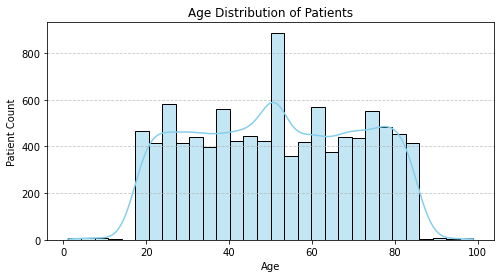

Median Age: 51.0


In [31]:
# Age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Patient Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Median Age:", df["Age"].median())

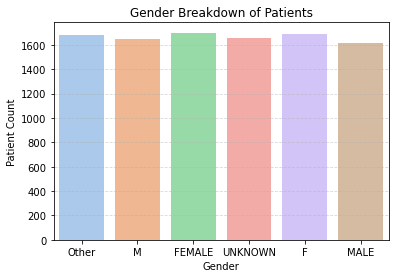

FEMALE     1700
F          1691
Other      1683
UNKNOWN    1658
M          1650
MALE       1618
Name: Gender, dtype: int64


In [32]:
# Gender Breakdown
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',data=df,palette="pastel")
plt.title("Gender Breakdown of Patients")
plt.xlabel("Gender")
plt.ylabel("Patient Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
print(df["Gender"].value_counts())

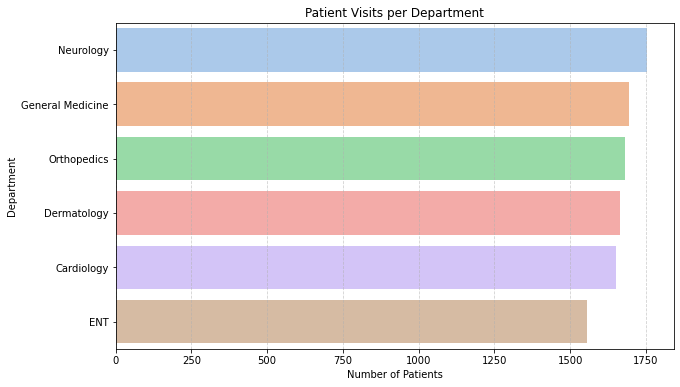

In [33]:
# Department Count
plt.figure(figsize=(10,6))
sns.countplot(y='Department',data=df,order=df['Department'].value_counts().index,palette='pastel')
plt.title("Patient Visits per Department")
plt.xlabel("Number of Patients")
plt.ylabel("Department")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

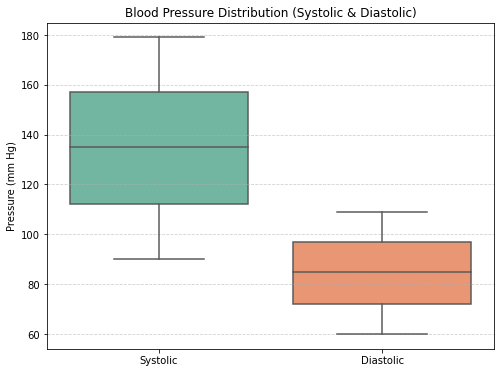

In [34]:
# Blood Pressure Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df[['Systolic', 'Diastolic']], palette='Set2')
plt.title("Blood Pressure Distribution (Systolic & Diastolic)")
plt.ylabel("Pressure (mm Hg)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [35]:
# Patient Visit Trend Over Time

# First, extract the month (format: YYYY-MM)
df["VisitMonth"] = df["VisitDate"].dt.to_period("M")

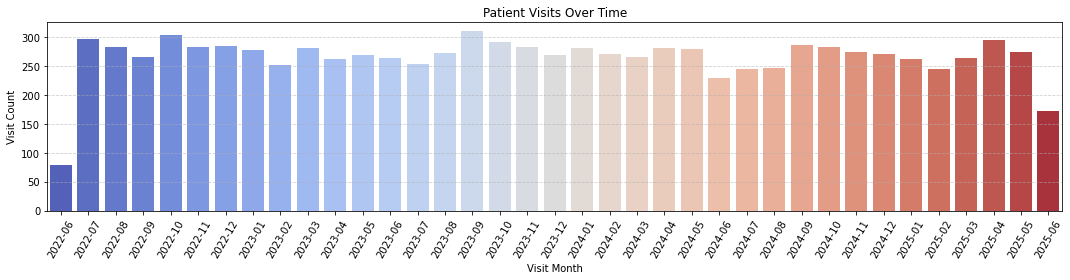

In [36]:
plt.figure(figsize=(15, 4))
sns.countplot(x='VisitMonth',data=df.sort_values("VisitMonth"),palette='coolwarm')
plt.title("Patient Visits Over Time")
plt.xlabel("Visit Month")
plt.ylabel("Visit Count")
plt.xticks(rotation=60)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [37]:
# Final snapshot
print("Final Dataset Shape:", df.shape)
print("Final Missing Values:")
print(df.isnull().sum())


Final Dataset Shape: (10000, 12)
Final Missing Values:
PatientID          0
Name              94
Gender             0
Age                0
VisitDate        190
Department         0
Diagnosis          0
BloodPressure      0
Notes              0
Systolic         501
Diastolic        501
VisitMonth       190
dtype: int64


## 🏁 Project Summary: Healthcare Data Cleaning & Visualization

### ✅ Key Cleaning Actions:
- Removed duplicates and standardized categorical fields like Gender and Diagnosis.
- Treated invalid or unrealistic values in Age and Blood Pressure.
- Converted VisitDate to datetime and handled corrupt formats.
- Cleaned placeholder values in free-text fields like Notes.

### 📊 Visual Insights:
1. **Age Distribution** – Most patients are between X and Y years old, median age is Z.
2. **Gender Breakdown** – Fairly balanced / skewed toward M/F/Other.
3. **Department Count** – Top visited departments are A, B, and C.
4. **Blood Pressure** – Mostly within medical range; few outliers noted.
5. **Visit Trend** – Seasonal peaks identified in MM/YYYY.

### 📦 Final Dataset Shape:
- Records: 10,000
- Cleaned Columns: 11 (including Systolic, Diastolic, VisitMonth)

In [38]:
# KPI Metrics
total_patients = df.shape[0]
median_age = df["Age"].median()
male_count = df[df["Gender"] == "M"].shape[0]
female_count = df[df["Gender"] == "F"].shape[0]
avg_systolic = df["Systolic"].mean()
avg_diastolic = df["Diastolic"].mean()

# Display KPIs
print(f"🧑‍⚕️ Total Patients: {total_patients}")
print(f"📊 Median Age: {median_age}")
print(f"♂️ Male Patients: {male_count}")
print(f"♀️ Female Patients: {female_count}")
print(f"🩺 Avg Systolic BP: {avg_systolic:.1f} mmHg")
print(f"🩺 Avg Diastolic BP: {avg_diastolic:.1f} mmHg")



🧑‍⚕️ Total Patients: 10000
📊 Median Age: 51.0
♂️ Male Patients: 1650
♀️ Female Patients: 1691
🩺 Avg Systolic BP: 134.6 mmHg
🩺 Avg Diastolic BP: 84.8 mmHg
